# 03 — Tokenisasi
**Resume Classification — Deep Learning Project**

Notebook ini mengubah teks resume menjadi token ID yang siap diproses model.

---
**Input  :** `data/processed/train.pkl`, `val.pkl`, `test.pkl`  
**Output :** `data/processed/train_tok.pkl`, `val_tok.pkl`, `test_tok.pkl`

---
### Mengapa ini penting?
Dari hasil EDA & Preprocessing diketahui:
- Rata-rata resume ~**2.025 token** (estimasi)
- **93.7%** resume melebihi batas 512 token BERT
- Hanya **4.4%** yang melebihi 4096 token

→ **Rekomendasi: Longformer** (`allenai/longformer-base-4096`) agar informasi tidak banyak hilang.  
→ Alternatif lebih ringan: **DistilBERT** dengan strategi truncation `head+tail`.

In [1]:
!pip install transformers torch datasets accelerate
import pandas as pd
import numpy as np
import pickle
import os
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

# ============================================================
# KONFIGURASI — ubah di sini sesuai pilihan model
# ============================================================
# Pilihan:
#   'allenai/longformer-base-4096'   ← REKOMENDASI (akurasi tinggi)
#   'distilbert-base-uncased'         ← lebih ringan & cepat
#   'bert-base-uncased'               ← standar BERT

MODEL_NAME  = 'distilbert-base-uncased'
MAX_LENGTH  = 512      # Longformer: 4096 | BERT/DistilBERT: 512
BATCH_SIZE  = 4        # Longformer butuh RAM besar, turunkan jika OOM
NUM_LABELS  = 9

PROCESSED_DIR = '../data/processed/'

# Deteksi device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Model    : {MODEL_NAME}')
print(f'Max len  : {MAX_LENGTH} token')
print(f'Device   : {DEVICE}')

C:\Users\ASUS\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model    : distilbert-base-uncased
Max len  : 512 token
Device   : cuda


## 1. Setup & Import Library

> **Catatan GPU:** Longformer dengan `max_length=4096` butuh VRAM ~12GB.
> Kalau pakai Google Colab Free (T4 ~15GB), set `BATCH_SIZE=4`.
> Kalau RAM tidak cukup, turunkan `MAX_LENGTH=2048` atau ganti ke DistilBERT.

## 2. Load Data Hasil Preprocessing

In [11]:
train_df = pd.read_pickle(os.path.join(PROCESSED_DIR, 'train.pkl'))
val_df   = pd.read_pickle(os.path.join(PROCESSED_DIR, 'val.pkl'))
test_df  = pd.read_pickle(os.path.join(PROCESSED_DIR, 'test.pkl'))

print(f'Train : {len(train_df):,} baris')
print(f'Val   : {len(val_df):,} baris')
print(f'Test  : {len(test_df):,} baris')
print()
train_df.head (5)

Train : 4,018 baris
Val   : 861 baris
Test  : 862 baris



,clean_text,label,category
0,Over years of IT experience in Various RDBMS D...,8,Web Developer Resumes
1,More than years of experience in Information T...,8,Web Developer Resumes
2,Having around years of experience in IT indust...,8,Web Developer Resumes
3,Around years of experience in Web Development ...,6,Recruiter Resumes
4,Proven experience in high level fast paced env...,2,"Datawarehousing, ETL, Informatica Resumes"


## 3. Load Tokenizer

In [12]:
# Download otomatis dari HuggingFace Hub (butuh internet pertama kali)
# Setelah itu di-cache di ~/.cache/huggingface/
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f'Tokenizer loaded: {MODEL_NAME}')
print(f'Vocab size      : {tokenizer.vocab_size:,}')

# Simpan tokenizer ke folder models/ untuk dipakai saat inference
os.makedirs('../models/', exist_ok=True)
tokenizer.save_pretrained('../models/tokenizer/')
print(f'Tokenizer disimpan ke: ../models/tokenizer/')

Tokenizer loaded: distilbert-base-uncased
Vocab size      : 30,522
Tokenizer disimpan ke: ../models/tokenizer/


## 4. Analisis Token Length

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1074 > 512). Running this sequence through the model will result in indexing errors


Rata-rata token : 1750
Median token    : 1633
Max token       : 5154
Min token       : 163

> 512  : 459 (91.8%)
> 1024 : 385 (77.0%)
> 4096 : 13 (2.6%)


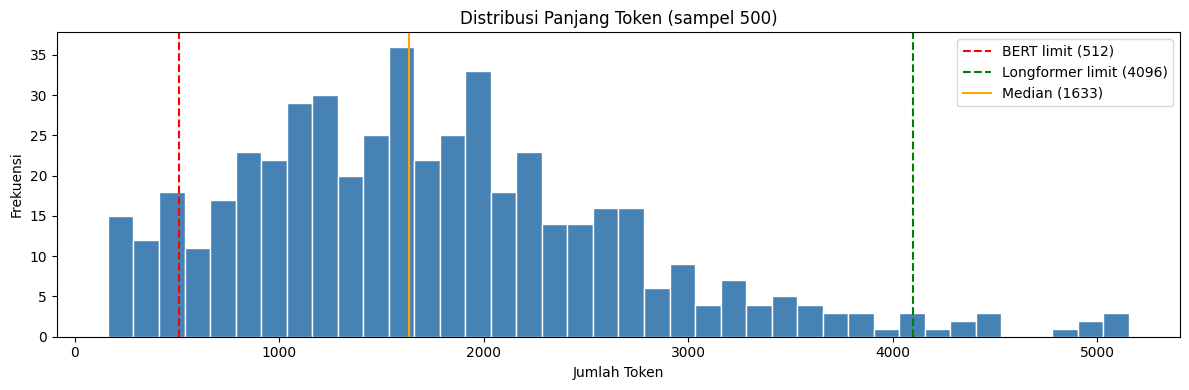

In [13]:
# Hitung panjang token aktual pada sampel 500 baris
# (tidak perlu semua karena tokenisasi lambat)
import matplotlib.pyplot as plt

sample_texts = train_df['clean_text'].sample(500, random_state=42).tolist()

token_lengths = [
    len(tokenizer.encode(text, add_special_tokens=True, truncation=False))
    for text in sample_texts
]

token_lengths = np.array(token_lengths)

print(f'Rata-rata token : {token_lengths.mean():.0f}')
print(f'Median token    : {np.median(token_lengths):.0f}')
print(f'Max token       : {token_lengths.max()}')
print(f'Min token       : {token_lengths.min()}')
print()
print(f'> 512  : {(token_lengths > 512).sum()} ({(token_lengths > 512).mean()*100:.1f}%)')
print(f'> 1024 : {(token_lengths > 1024).sum()} ({(token_lengths > 1024).mean()*100:.1f}%)')
print(f'> 4096 : {(token_lengths > 4096).sum()} ({(token_lengths > 4096).mean()*100:.1f}%)')

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(token_lengths, bins=40, color='steelblue', edgecolor='white')
ax.axvline(512,  color='red',    linestyle='--', label='BERT limit (512)')
ax.axvline(4096, color='green',  linestyle='--', label='Longformer limit (4096)')
ax.axvline(int(np.median(token_lengths)), color='orange', linestyle='-', label=f'Median ({int(np.median(token_lengths))})')
ax.set_xlabel('Jumlah Token')
ax.set_ylabel('Frekuensi')
ax.set_title('Distribusi Panjang Token (sampel 500)')
ax.legend()
plt.tight_layout()
plt.savefig('../data/tokenization_length_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Definisi PyTorch Dataset

In [15]:
class ResumeDataset(Dataset):
    """
    PyTorch Dataset untuk resume classification.
    Kompatibel dengan BERT, DistilBERT, dan Longformer.
    """

    def __init__(self, dataframe: pd.DataFrame, tokenizer, max_length: int):
        self.texts      = dataframe['clean_text'].tolist()
        self.labels     = dataframe['label'].tolist()
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text  = self.texts[idx]
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            max_length      = self.max_length,
            padding         = 'max_length',
            truncation      = True,
            return_tensors  = 'pt',
        )

        item = {
            'input_ids'      : encoding['input_ids'].squeeze(0),
            'attention_mask' : encoding['attention_mask'].squeeze(0),
            'label'          : torch.tensor(label, dtype=torch.long),
        }

        # Longformer butuh global_attention_mask pada token [CLS]
        if 'longformer' in self.tokenizer.name_or_path.lower():
            global_attention_mask = torch.zeros_like(item['input_ids'])
            global_attention_mask[0] = 1   # aktifkan global attention di [CLS]
            item['global_attention_mask'] = global_attention_mask

        return item


print('Class ResumeDataset berhasil didefinisikan.')

Class ResumeDataset berhasil didefinisikan.


## 6. Buat Dataset & DataLoader

In [16]:
train_dataset = ResumeDataset(train_df, tokenizer, MAX_LENGTH)
val_dataset   = ResumeDataset(val_df,   tokenizer, MAX_LENGTH)
test_dataset  = ResumeDataset(test_df,  tokenizer, MAX_LENGTH)

print(f'Train dataset : {len(train_dataset):,} sampel')
print(f'Val dataset   : {len(val_dataset):,} sampel')
print(f'Test dataset  : {len(test_dataset):,} sampel')

# Cek satu sampel
sample = train_dataset[0]
print()
print('Keys dalam satu sampel:', list(sample.keys()))
print('input_ids shape        :', sample['input_ids'].shape)
print('attention_mask shape   :', sample['attention_mask'].shape)
print('label                  :', sample['label'].item())

Train dataset : 4,018 sampel
Val dataset   : 861 sampel
Test dataset  : 862 sampel

Keys dalam satu sampel: ['input_ids', 'attention_mask', 'label']
input_ids shape        : torch.Size([512])
attention_mask shape   : torch.Size([512])
label                  : 8


In [17]:
train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = 0,       # set ke 2-4 jika CPU kuat
    pin_memory  = True if DEVICE.type == 'cuda' else False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 0,
    pin_memory  = True if DEVICE.type == 'cuda' else False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 0,
    pin_memory  = True if DEVICE.type == 'cuda' else False,
)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

# Cek satu batch
batch = next(iter(train_loader))
print()
print('Bentuk satu batch:')
for key, val in batch.items():
    print(f'  {key:25s}: {val.shape}')

Train batches : 1005
Val batches   : 216
Test batches  : 216

Bentuk satu batch:
  input_ids                : torch.Size([4, 512])
  attention_mask           : torch.Size([4, 512])
  label                    : torch.Size([4])


## 7. Simpan Dataset & DataLoader

In [18]:
# Simpan Dataset object (bukan tokenized tensor) agar bisa di-load ulang
# tanpa harus tokenisasi ulang dari awal

datasets = {
    'train' : train_dataset,
    'val'   : val_dataset,
    'test'  : test_dataset,
}

for name, dataset in datasets.items():
    path = os.path.join(PROCESSED_DIR, f'{name}_dataset.pkl')
    with open(path, 'wb') as f:
        pickle.dump(dataset, f)
    size = os.path.getsize(path) / (1024 * 1024)
    print(f'Disimpan: {path}  ({size:.1f} MB)')

Disimpan: ../data/processed/train_dataset.pkl  (42.1 MB)
Disimpan: ../data/processed/val_dataset.pkl  (10.1 MB)
Disimpan: ../data/processed/test_dataset.pkl  (9.7 MB)


> **Catatan:** Kalau ukuran file terlalu besar (>500MB), lewati langkah simpan dataset dan biarkan notebook training membuat ulang dataset dari `train.pkl` langsung. Cukup pastikan class `ResumeDataset` di-copy ke notebook training.

## 8. Verifikasi Tokenisasi

In [19]:
# Decode balik satu sampel untuk memastikan tokenisasi benar
sample     = train_dataset[0]
input_ids  = sample['input_ids']

# Hitung token non-padding
n_real_tokens = (input_ids != tokenizer.pad_token_id).sum().item()
print(f'Total token (termasuk padding) : {len(input_ids)}')
print(f'Token non-padding              : {n_real_tokens}')
print()

# Decode 30 token pertama
decoded = tokenizer.decode(input_ids[:30], skip_special_tokens=False)
print('30 token pertama (decoded):')
print(decoded)
print()

# Bandingkan dengan teks asli
print('Teks asli (150 karakter pertama):')
print(train_df['clean_text'].iloc[0][:150])

Total token (termasuk padding) : 512
Token non-padding              : 512

30 token pertama (decoded):
[CLS] over years of it experience in various rdbms data warehousing etl olap tools and client server applications years of hands on experience in

Teks asli (150 karakter pertama):
Over years of IT experience in Various RDBMS Data warehousing ETL OLAP Tools and Client Server applications years of Hands on experience in Data wareh


## 9. Ringkasan

In [20]:
print('=' * 60)
print('RINGKASAN TOKENISASI')
print('=' * 60)
print(f"""
KONFIGURASI
  Model / Tokenizer : {MODEL_NAME}
  Max length        : {MAX_LENGTH} token
  Batch size        : {BATCH_SIZE}
  Device            : {DEVICE}

DATASET
  Train   : {len(train_dataset):,} sampel  ({len(train_loader)} batch)
  Val     : {len(val_dataset):,} sampel  ({len(val_loader)} batch)
  Test    : {len(test_dataset):,} sampel  ({len(test_loader)} batch)

OUTPUT
  data/processed/train_dataset.pkl
  data/processed/val_dataset.pkl
  data/processed/test_dataset.pkl
  models/tokenizer/

CATATAN UNTUK NOTEBOOK BERIKUTNYA
  - Gunakan train_loader untuk training loop
  - Gunakan val_loader untuk evaluasi tiap epoch
  - Longformer: pastikan global_attention_mask
    diteruskan ke model saat forward pass
  - Jika OOM: turunkan BATCH_SIZE atau MAX_LENGTH
""")
print('=' * 60)
print('Lanjut ke: 04_training.ipynb')

RINGKASAN TOKENISASI

KONFIGURASI
  Model / Tokenizer : distilbert-base-uncased
  Max length        : 512 token
  Batch size        : 4
  Device            : cuda

DATASET
  Train   : 4,018 sampel  (1005 batch)
  Val     : 861 sampel  (216 batch)
  Test    : 862 sampel  (216 batch)

OUTPUT
  data/processed/train_dataset.pkl
  data/processed/val_dataset.pkl
  data/processed/test_dataset.pkl
  models/tokenizer/

CATATAN UNTUK NOTEBOOK BERIKUTNYA
  - Gunakan train_loader untuk training loop
  - Gunakan val_loader untuk evaluasi tiap epoch
  - Longformer: pastikan global_attention_mask
    diteruskan ke model saat forward pass
  - Jika OOM: turunkan BATCH_SIZE atau MAX_LENGTH

Lanjut ke: 04_training.ipynb
